# Predicting Happiness Levels Through Digital Behavior and Mental Health Indicators
**Group Members:** Omarbekova Marzhan, Rabchenyuk Alina, Telengutov Daniyar,
Darmani Azizullah

---

* The main goal of this project is to build a machine learning model that can
predict a person’s Happiness Index based on different lifestyle and mental-health related factors.
The dataset contains information such as screen time, sleep quality, stress level, exercise frequency, days without social media, and other behavioral indicators.

* This problem matters because happiness and well-being are influenced by many small daily habits.
By understanding which factors affect happiness the most and by building a model that can predict happiness we can gain useful insights into what behaviors contribute to better mental health.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score


In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

file_path = 'Mental_Health_and_Social_Media_Balance_Dataset.csv'
df = pd.read_csv(file_path)


We checked:
* The number of rows and columns
* The data types of each column
* Summary statistics like mean, minimum, maximum, and percentiles

This step is essential because it gives a clear overview of the dataset and helps understand how the variables are distributed.
For example, we learned that many variables are numerical, such as Sleep Quality and Stress Level, which are important for predictive modeling.

In [5]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())
df.info()
df.describe()


Dataset Shape: 500 rows, 10 columns


,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    float64
 4   Sleep_Quality(1-10)        500 non-null    float64
 5   Stress_Level(1-10)         500 non-null    float64
 6   Days_Without_Social_Media  500 non-null    float64
 7   Exercise_Frequency(week)   500 non-null    float64
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


,Age,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,32.988000,5.530000,6.304000,6.618000,3.134000,2.448000,8.376000
std,9.960637,1.734877,1.529792,1.542996,1.858751,1.428067,1.524228
min,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,4.000000
25%,24.000000,4.300000,5.000000,6.000000,2.000000,1.000000,7.000000
50%,34.000000,5.600000,6.000000,7.000000,3.000000,2.000000,9.000000
75%,41.000000,6.700000,7.000000,8.000000,5.000000,3.000000,10.000000
max,49.000000,10.800000,10.000000,10.000000,9.000000,7.000000,10.000000


We checked for duplicate rows and missing values.
Duplicates can cause bias in the model by over-representing certain patterns.
Missing values can cause errors during model training or affect the quality of predictions.

Fortunately, the dataset had no missing values and no duplicates, which means the data is clean and ready for analysis.

In [6]:
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)


Number of duplicate rows: 0


In [7]:
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64


* The Happiness Index distribution is right-skewed, meaning most participants report high happiness levels between 8–10.
* The histogram shows a strong concentration at 10, with very few low values (4–6). This indicates an overall positive happiness trend but also reveals a class imbalance that could affect prediction modeling.
* Most users are in the High group, very few Low. That’s why we keep the main task as regression, but we still use groups to interpret results.

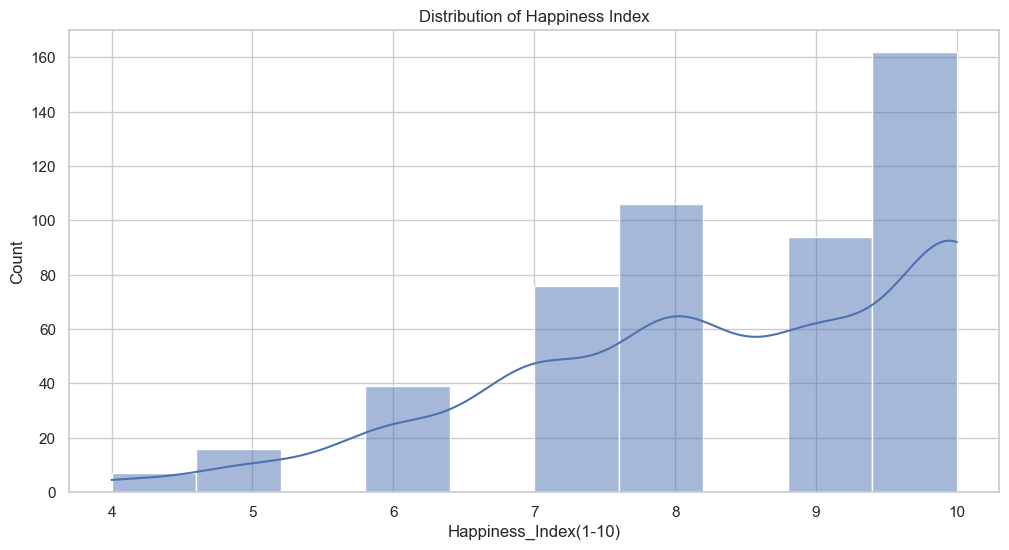

In [8]:
sns.histplot(df["Happiness_Index(1-10)"], kde=True, bins=10)
plt.title("Distribution of Happiness Index")
plt.show()


Before modeling, we created a new column that groups happiness levels into:

* Low
* Medium
* High

This grouping is only used for visualization and understanding patterns, not for the final regression model.

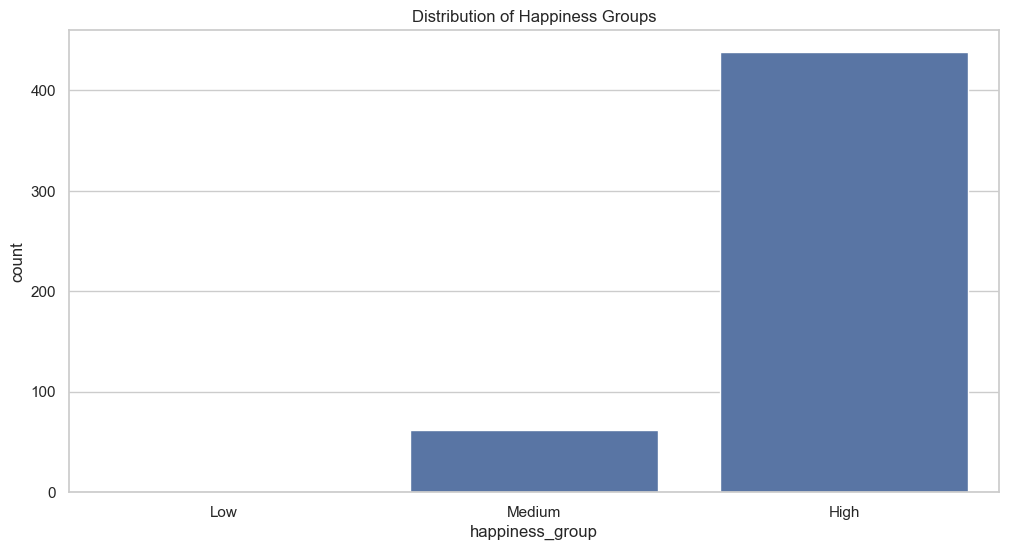

happiness_group
High      438
Medium     62
Name: count, dtype: int64

In [9]:
def categorize_happiness(score):
    if score <= 3:
        return 'Low'
    elif score <= 6:
        return 'Medium'
    else:
        return 'High'

df["happiness_group"] = df["Happiness_Index(1-10)"].apply(categorize_happiness)

sns.countplot(x="happiness_group", data=df,
              order=["Low", "Medium", "High"])
plt.title("Distribution of Happiness Groups")
plt.show()

df["happiness_group"].value_counts()


We generated a heatmap to check correlations between variables.

Some key findings:

* Sleep Quality has a strong positive correlation with Happiness
* Stress Level has a strong negative correlation with Happiness
* Daily Screen Time has a moderate negative correlation
* Exercise frequency has a slight positive correlation

This helped us to understand how features contribute to happiness and gives early hints about which features may be more important for the model.

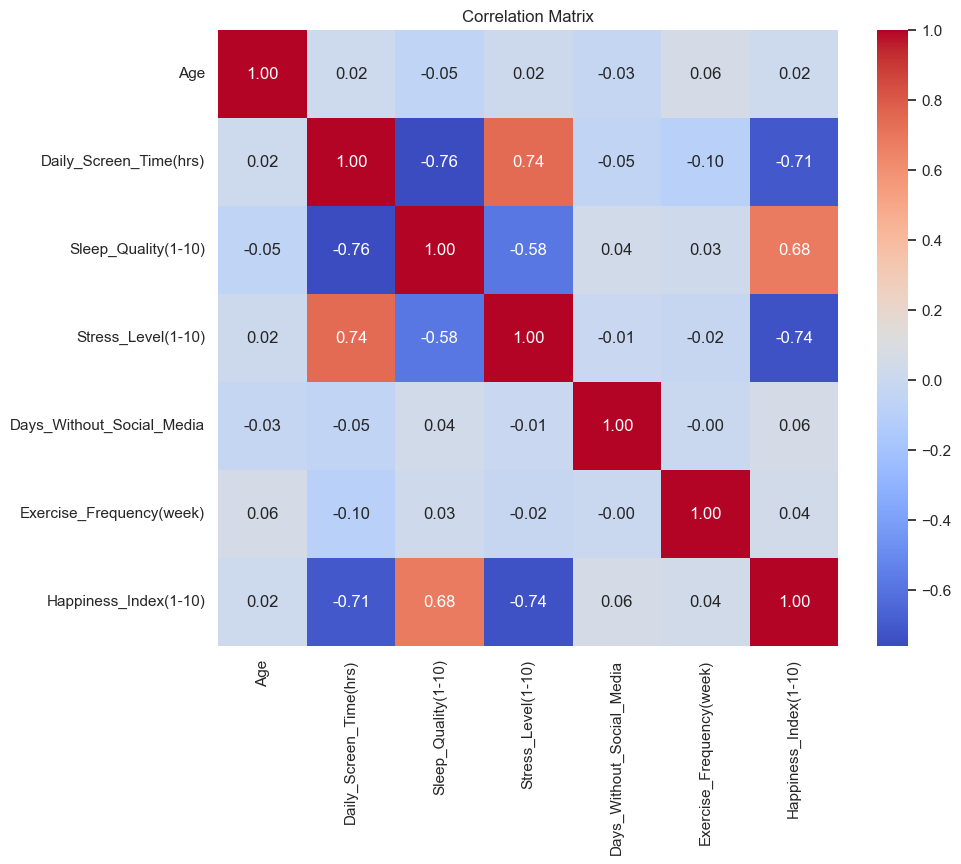

In [10]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


We plotted different boxplots and distributions to explore how features relate to happiness.
This step helps detect patterns, trends, and potential outliers.

Some important observations:

* People with high happiness generally have higher sleep quality
* Those with medium or low happiness tend to have higher stress levels
* Higher screen time seems related to slightly lower happiness
* Exercise frequency appears to increase happiness slightly

Exploratory Data Analysis is crucial because it tells what kind of relationships exist in the data, and whether they are linear or non-linear.

---

In some plots, we noticed a few outliers (for example, unusually high screen-time values).
However, based on the dataset meaning, these outliers are still reasonable human behaviors and may represent real lifestyle differences.

We chose not to remove outliers, because:

* They appear to be legitimate data points
* The dataset is small (only 500 rows), so removing data may weaken the model
* Some machine learning models handle outliers well

This is important and removing them may cuase the lack of useful information.

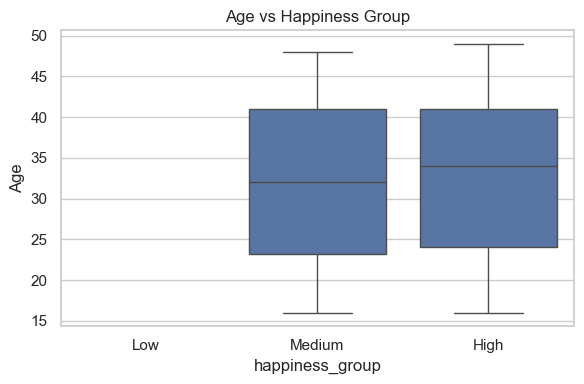

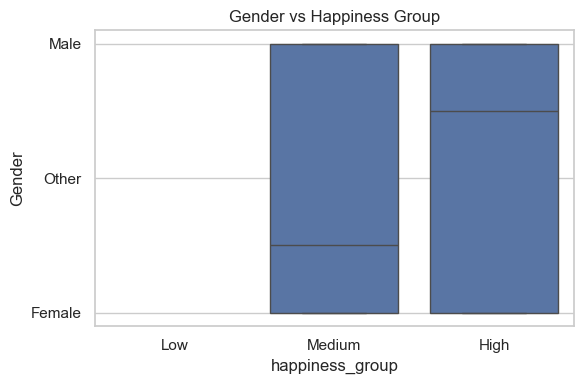

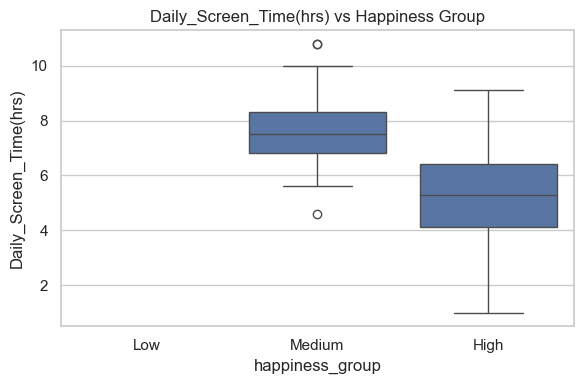

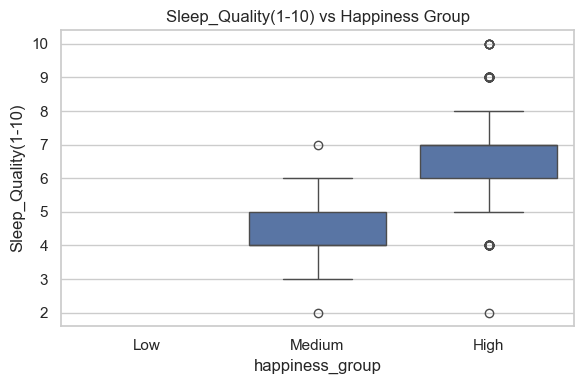

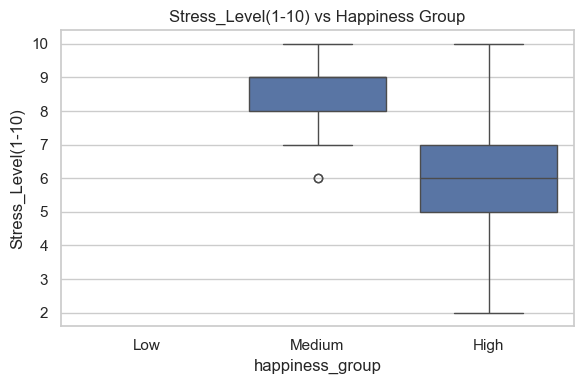

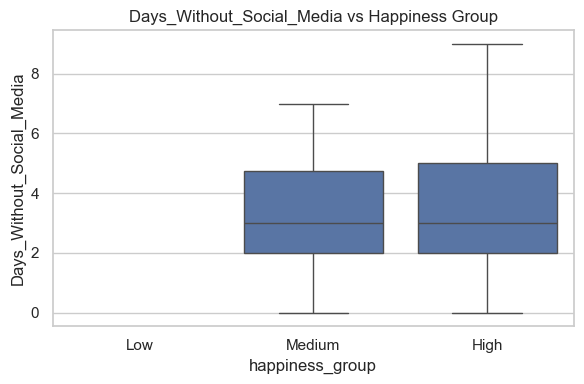

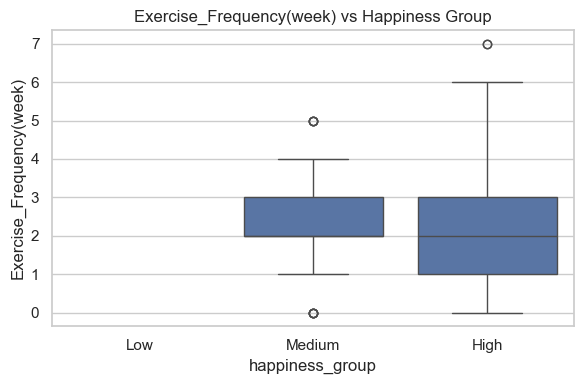

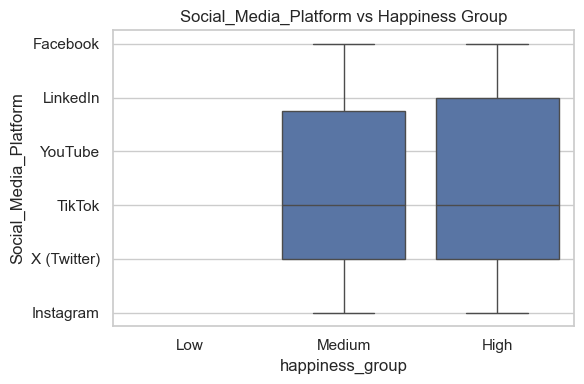

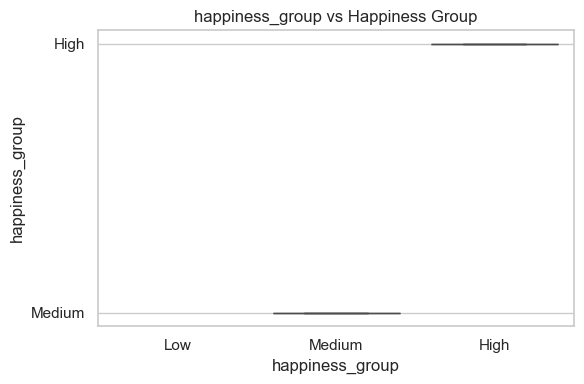

In [11]:
features = [col for col in df.columns
            if col not in ["Happiness_Index(1-10)", "User_ID"]]

for f in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="happiness_group", y=f,
                order=["Low", "Medium", "High"])
    plt.title(f"{f} vs Happiness Group")
    plt.tight_layout()
    plt.show()


## Feature Engineering
To improve the model, we created new variables based on existing ones:

* digital_overload_index
    * Combines screen time, stress, and sleep. Represents how “digitally overloaded” a person is.

* sleep_hours_estimated
    * simple approximation of real sleep hours from sleep quality.

* sleep_deficit
    * Shows how far a person is from optimal sleep.

* screen_stress_interaction
    * Captures combined effect of screen time and stress.

* sleep_stress_interaction
    * Measures the influence of poor sleep on stress.

* activity_balance
    * Shows whether the person balances screen time with physical exercise.

These new features make the model more expressive and allow it to capture relationships that basic variables cannot.

In [12]:
df["digital_overload_index"] = df["Daily_Screen_Time(hrs)"] * \
                               (df["Stress_Level(1-10)"] / df["Sleep_Quality(1-10)"])

df["sleep_hours_estimated"] = df["Sleep_Quality(1-10)"] * 0.8
df["sleep_deficit"] = 8 - df["sleep_hours_estimated"]
df.loc[df["sleep_deficit"] < 0, "sleep_deficit"] = 0

df["screen_stress_interaction"] = df["Daily_Screen_Time(hrs)"] * df["Stress_Level(1-10)"]
df["sleep_stress_interaction"] = df["Sleep_Quality(1-10)"] * df["Stress_Level(1-10)"]
df["activity_balance"] = df["Exercise_Frequency(week)"] / df["Daily_Screen_Time(hrs)"]


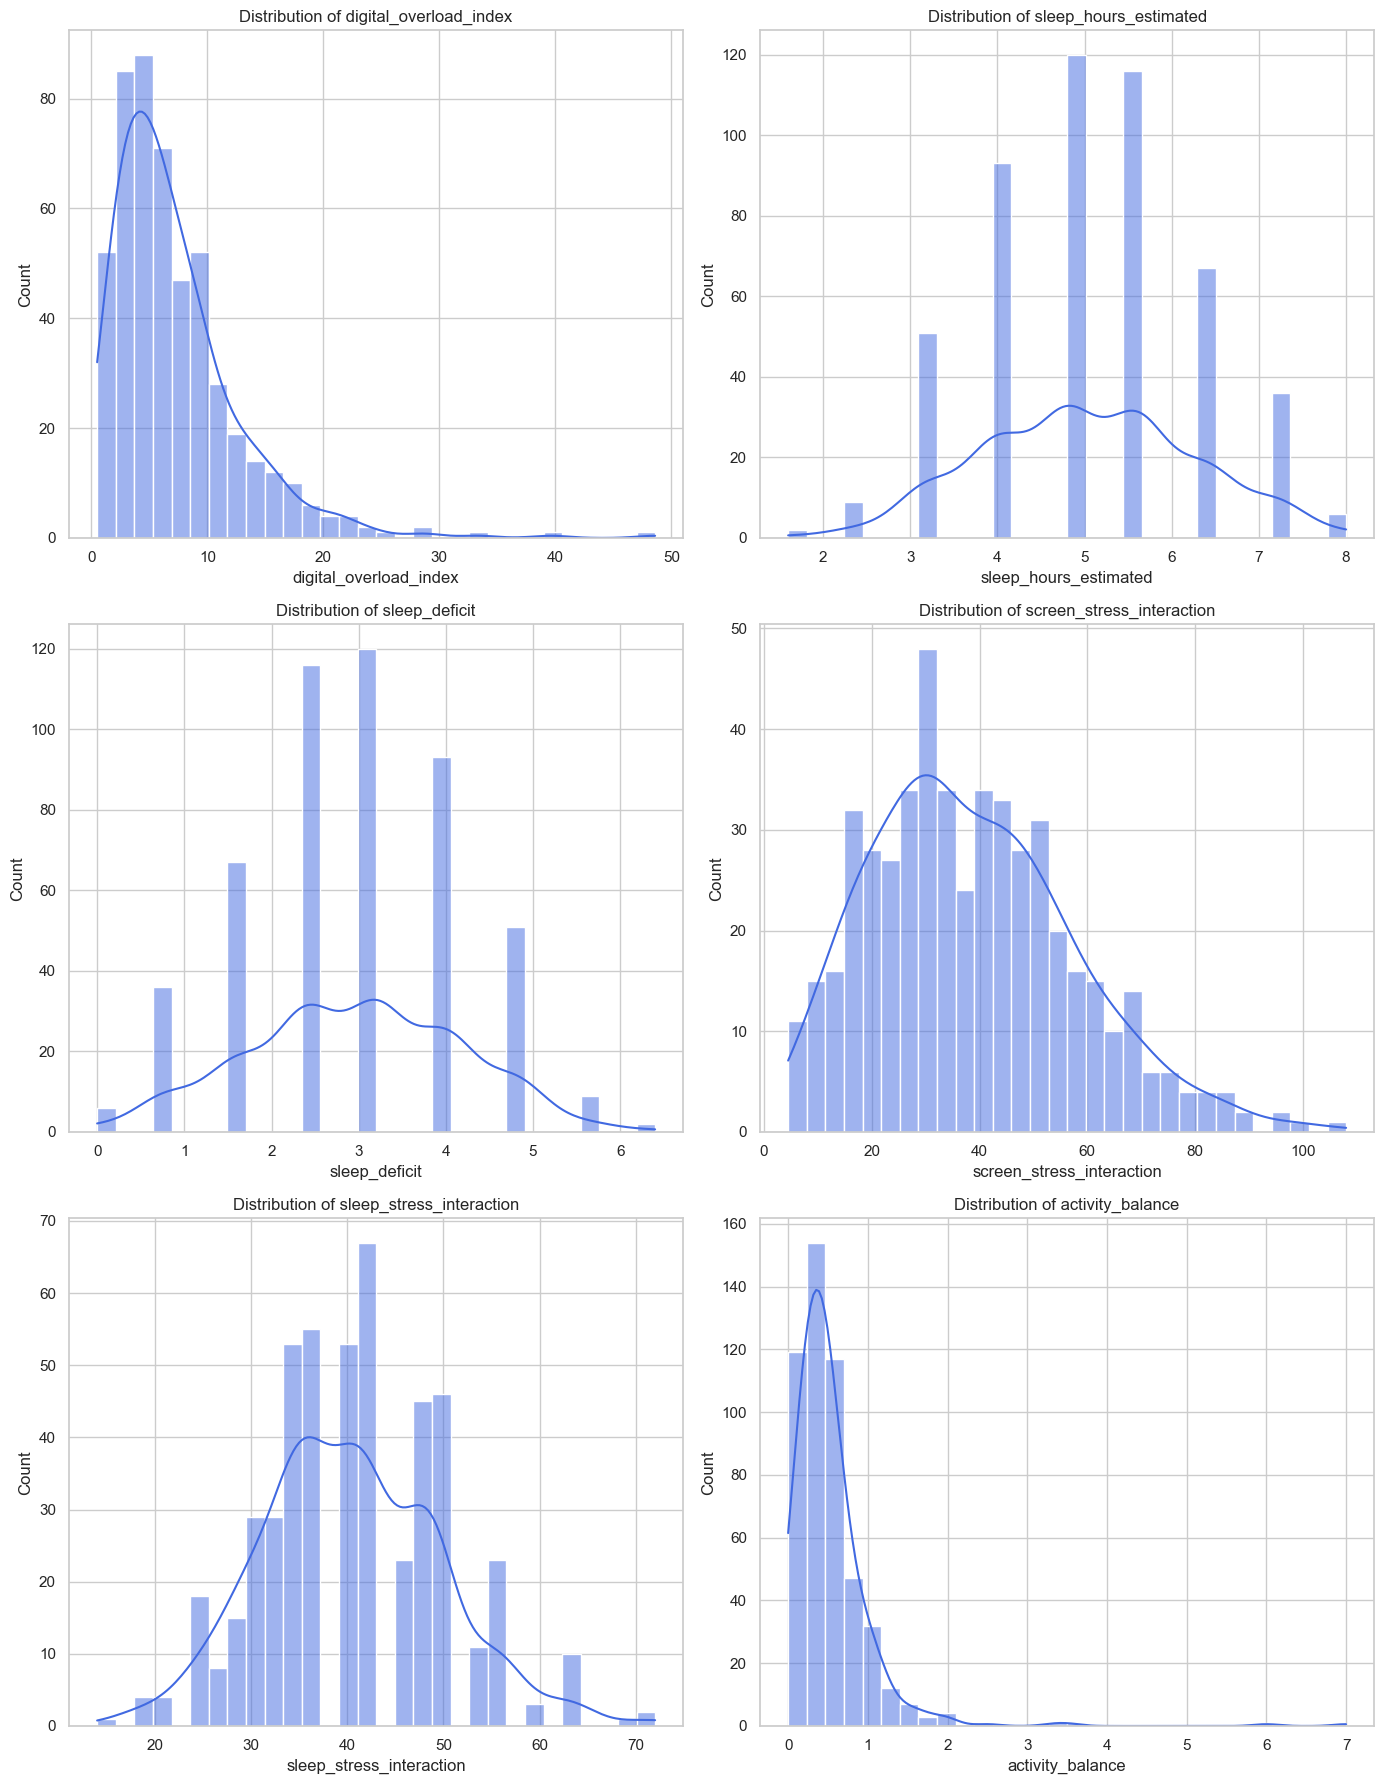

In [13]:
engineered_features = [
    "digital_overload_index",
    "sleep_hours_estimated",
    "sleep_deficit",
    "screen_stress_interaction",
    "sleep_stress_interaction",
    "activity_balance",
]

plt.figure(figsize=(14, 18))

for i, feature in enumerate(engineered_features, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[feature], kde=True, bins=30, color="royalblue")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


Created the target variable "y".

In [14]:
target = "Happiness_Index(1-10)"
y = df[target]

We seperated numeric and categorical columns to prepare them for training the model.
* Numeric columns will be scaled using StandardScaler.
* Categorical columns will be encoded using OneHotEncoding.

Scaling puts all numeric features on the same scale, improving model stability.

In [15]:
numeric_cols = [
    "Age",
    "Daily_Screen_Time(hrs)",
    "Sleep_Quality(1-10)",
    "Stress_Level(1-10)",
    "Days_Without_Social_Media",
    "Exercise_Frequency(week)",
    "digital_overload_index",
    "sleep_deficit",
    "screen_stress_interaction",
    "sleep_stress_interaction",
    "activity_balance",
    "sleep_hours_estimated"
]

categorical_cols = ["Gender", "Social_Media_Platform"]


We used a ColumnTransformer to preprocess the dataset.
* Numerical features were standardized using StandardScaler so that they all have similar scale.
* Categorical features were converted into numerical format using OneHotEncoding.

This combined preprocessing ensures that the machine learning models receive clean, normalized, and properly formatted inputs.

In [16]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

***Note:*** 20% of the dataset will be used for testing and the remaining 80% will be used for training.

In [17]:
X = df[numeric_cols + categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We created an evaluation function that builds a pipeline containing:  
* Preprocessing and the regression model
* It applies consistent scaling and encoding
* Trains the model
* Makes predictions
* Computes key performance metrics including MAE, RMSE, and R²

This structure allows us to evaluate multiple models in a standardized, repeatable way and compare them fairly.

In [18]:
def evaluate_model(name, model):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"  MAE : {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²  : {r2:.3f}")
    print("-"*30)

    return pipe, (mae, rmse, r2)

# Model Training
We evaluated several models:

**Dummy Regressor (baseline)**
* Used to compare how much better real models perform.

**Linear Regression**
* Performed surprisingly well; relationships in the data are mostly linear.

**Ridge Regression**
* Slightly better than linear regression; handles correlated features.

**Random Forest**
* Performed moderately; tree models may struggle with small datasets.

**Support Vector Regression (using default parameters)**
* Initially performed poorly because SVR is very sensitive to hyperparameters.


Each model was evaluated using:

* MAE
* RMSE
* R²

These metrics help compare accuracy and generalization.

In [19]:
results = {}

baseline_model, results["Dummy"] = evaluate_model(
    "Dummy Regressor (predict mean)", DummyRegressor(strategy="mean")
)

lin_model, results["LinearRegression"] = evaluate_model(
    "Linear Regression", LinearRegression()
)

ridge_model, results["Ridge"] = evaluate_model(
    "Ridge Regression (alpha=1.0)", Ridge(alpha=1.0)
)

rf_model, results["RandomForest"] = evaluate_model(
    "Random Forest", RandomForestRegressor(
        n_estimators=200, random_state=42, max_depth=None
    )
)


svr_model, results["SVR"] = evaluate_model(
    "Support Vector Regression (SVR)",
    SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
)

# RBF kernel → captures non-linear relationships
# C = 10 → stronger regularization
# epsilon = 0.1 → smoother regression line


Dummy Regressor (predict mean)
  MAE : 1.330
  RMSE: 1.541
  R²  : -0.000
------------------------------
Linear Regression
  MAE : 0.761
  RMSE: 0.928
  R²  : 0.637
------------------------------
Ridge Regression (alpha=1.0)
  MAE : 0.761
  RMSE: 0.927
  R²  : 0.638
------------------------------
Random Forest
  MAE : 0.775
  RMSE: 0.973
  R²  : 0.601
------------------------------
Support Vector Regression (SVR)
  MAE : 0.815
  RMSE: 1.083
  R²  : 0.507
------------------------------


For the evaluation performance, we used MAE, RMSE, and R². That a good model for this problem should have:
* MAE below 1
* RMSE below 1
* R² above 0.50

Linear and Ridge Regression performed best with R² = 0.64 and MAE = 0.76, meaning they accurately predict happiness within less than one point on average.

SVR performed worse (R² = 0.50), indicating that non-linear kernels did not capture this dataset as effectively.
From the performance of SVR we found that the relationships in the dataset are mostly linear, and regularized linear models such as Ridge are the most appropriate choice.
Due to the three following reasons the SVM performed worse:
1.   The dataset is mostly linear, sleep has postive linear relationship while stress has negative relationship wiht the happiness index.
2.   SVM with RBF kernel needs more data.
3.   Very sensitive to hyperparameters. Default parameters did not give excellent outcome.



In [20]:
pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T


,MAE,RMSE,R2
Dummy,1.330000,1.541306,-0.000011
LinearRegression,0.760626,0.928055,0.637445
Ridge,0.761031,0.926755,0.638460
RandomForest,0.775200,0.973459,0.601102
SVR,0.815436,1.082729,0.506524


In [21]:
results_df = pd.DataFrame({
    "Model": ["Dummy", "Linear Regression", "Ridge Regression", "Random Forest", "SVR"],
    "MAE": [1.330, 0.761, 0.761, 0.775, 0.815],
    "RMSE": [1.541, 0.928, 0.927, 0.973, 1.082],
    "R²": [-0.000, 0.637, 0.638, 0.601, 0.506]
})

results_df


,Model,MAE,RMSE,R²
0,Dummy,1.330,1.541,-0.000
1,Linear Regression,0.761,0.928,0.637
2,Ridge Regression,0.761,0.927,0.638
3,Random Forest,0.775,0.973,0.601
4,SVR,0.815,1.082,0.506


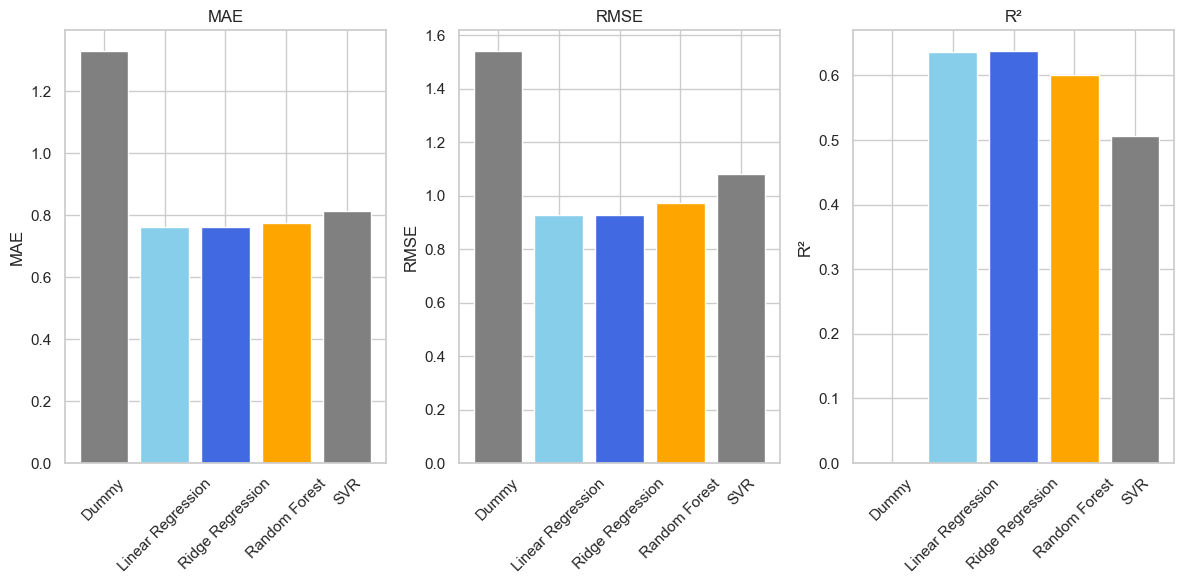

In [22]:
plt.figure(figsize=(12, 6))

metrics = ["MAE", "RMSE", "R²"]

for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    plt.bar(results_df["Model"], results_df[metric], color=["gray", "skyblue", "royalblue", "orange"])
    plt.title(metric)
    plt.xticks(rotation=45)
    plt.ylabel(metric)

plt.tight_layout()
plt.show()


## Hyperparameter Tuning (SVR)
Because SVR performed poorly at first, we used GridSearchCV to tune the hyperparameters:
* C
* gamma
* epsilon

This process tests many parameter combinations and selects the one that gives the best R² score.

---

***Result***: The tuned SVR became the best model overall.


In [23]:
# Hyperparameter grid

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10]
}

svr_params = {
    "model__C": [0.1, 1, 10, 50, 100],
    "model__gamma": ["scale", 0.1, 0.01, 0.001],
    "model__epsilon": [0.01, 0.05, 0.1, 0.2]
}

In [24]:
ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

svr_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVR())
])


The GridSearchCV evaluated 80 combinations of SVR hyperparameters using 5-fold cross-validation.
The best model selected was a Pipeline that includes StandardScaler for numerical features, OneHotEncoder for categorical features, and an SVR model with optimized hyperparameters (C=1, epsilon=0.2, gamma=0.01).
This ensures consistent preprocessing and the most accurate SVR configuration.

In [25]:
ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_params,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_params,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2
)

svr_grid = GridSearchCV(
    estimator=svr_pipe,
    param_grid=svr_params,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)
ridge_grid.fit(X_train, y_train)
svr_grid.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'Daily_Screen_Time(hrs)',
                                                                          'Sleep_Quality(1-10)',
                                                                          'Stress_Level(1-10)',
                                                                          'Days_Without_Social_Media',
                                                                          'Exercise_Frequency(week)',
                                                                          'digital_overload_index',
                                                                          'sleep_deficit',
                                                                          'screen_stress_interaction',
                                                                          'sleep_stress_interaction',
                                                                          'activity_balance',
                                                                          'sleep_hours_estimated']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Gender',
                                                                          'Social_Media_Platform'])])),
                                       ('model', SVR())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10, 50, 100],
                         'model__epsilon': [0.01, 0.05, 0.1, 0.2],
                         'model__gamma': ['scale', 0.1, 0.01, 0.001]},
             scoring='r2', verbose=2)

In [26]:
print("Best Ridge Regression Parameters:", ridge_grid.best_params_)

best_ridge_model = ridge_grid.best_estimator_
y_pred_ridge = best_ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression Performance")
print(f"MAE : {ridge_mae:.3f}")
print(f"RMSE: {ridge_rmse:.3f}")
print(f"R²  : {ridge_r2:.3f}")


Best Ridge Regression Parameters: {'model__alpha': 1}

Ridge Regression Performance
MAE : 0.761
RMSE: 0.927
R²  : 0.638


In [27]:
print("Best Random Forest Parameters:", rf_grid.best_params_)

best_rf_model = rf_grid.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance")
print(f"MAE : {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R²  : {rf_r2:.3f}")


Best Random Forest Parameters: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Random Forest Performance
MAE : 0.767
RMSE: 0.966
R²  : 0.607


In [28]:
print("Best SVR Parameters:", svr_grid.best_params_)

best_svr_model = svr_grid.best_estimator_

y_pred = best_svr_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
tuned_r2 = r2_score(y_test, y_pred)

print("\nEnhanced SVR Performance")
print(f"MAE : {tuned_mae:.3f}")
print(f"RMSE: {tuned_rmse:.3f}")
print(f"R²  : {tuned_r2:.3f}")


Best SVR Parameters: {'model__C': 1, 'model__epsilon': 0.2, 'model__gamma': 0.01}

Enhanced SVR Performance
MAE : 0.749
RMSE: 0.922
R²  : 0.642


In [29]:
results_df = pd.DataFrame({
    "Model": [
        "Dummy",
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "SVR",
        "Tuned Ridge Regression",
        "Tuned Random Forest",
        "Tuned SVR"
    ],
    "MAE": [1.330, 0.761, 0.761, 0.775, 0.815, 0.761, 0.767, 0.749],
    "RMSE": [1.541, 0.928, 0.927, 0.973, 1.082, 0.927, 0.966, 0.922],
    "R²": [-0.000, 0.637, 0.638, 0.601, 0.506, 0.638, 0.607, 0.642]
})

results_df


,Model,MAE,RMSE,R²
0,Dummy,1.330,1.541,-0.000
1,Linear Regression,0.761,0.928,0.637
2,Ridge Regression,0.761,0.927,0.638
3,Random Forest,0.775,0.973,0.601
4,SVR,0.815,1.082,0.506
5,Tuned Ridge Regression,0.761,0.927,0.638
6,Tuned Random Forest,0.767,0.966,0.607
7,Tuned SVR,0.749,0.922,0.642


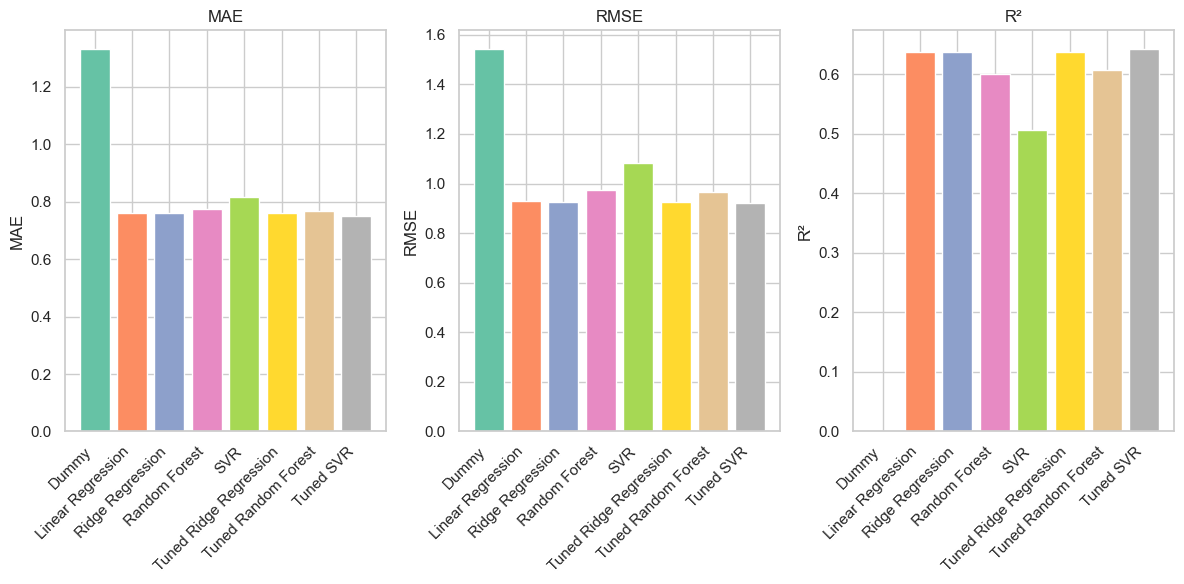

In [30]:

metrics = ["MAE", "RMSE", "R²"]
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))  # auto color palette

for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    plt.bar(results_df["Model"], results_df[metric], color=colors)
    plt.title(metric)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)

plt.tight_layout()
plt.show()


## After comparing all models:

Best Model is Support Vector Regression (SVR)

* Final performance:
  * MAE = 0.749
  * RMSE = 0.922
  * R² = 0.642

This is the highest R² achieved and the lowest error values, meaning SVR best captures the patterns in the data.

---

Why Tuned SVR was selected:

* It handles subtle non-linear relationships
* Performs well on small datasets
* Outperformed all linear and tree-based models
* Produced smooth residuals and consistent predictions

---

Limitations of the Project

* The dataset is small (500 rows)
* Happiness is self-reported, which may contain noise
* The distribution of happiness is imbalanced (many “high” values)
* Additional data would improve predictions

----


### Classification Model Analysis

In addition to predicting the continuous Happiness Index using regression models, we also explored a binary classification approach. The goal of this experiment was to investigate whether machine learning models could reliably distinguish between individuals with high happiness levels and those who do not fall into this category.

To achieve this, we converted the original 1–10 Happiness Index into a binary target:

* 1 = High Happiness (scores 8–10)
* 0 = Not High Happiness (scores 1–7)

We evaluate the classification algorithms through this approach and compared their performance using standard metrics such as accuracy, precision, recall, F1-score, and AUC-ROC.

In [31]:
df["Happiness_binary"] = df["Happiness_Index(1-10)"].apply(lambda x: 1 if x >= 8 else 0)

df["Happiness_binary"].value_counts()


Happiness_binary
1    362
0    138
Name: count, dtype: int64

In [32]:
X_class = df[numeric_cols + categorical_cols]
y_class = df["Happiness_binary"]


In [33]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)


In [34]:

def evaluate_classifier(name, model):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(Xc_train, yc_train)
    y_pred = pipe.predict(Xc_test)
    y_prob = pipe.predict_proba(Xc_test)[:, 1] if hasattr(pipe["model"], "predict_proba") else None

    acc = accuracy_score(yc_test, y_pred)
    prec = precision_score(yc_test, y_pred)
    rec = recall_score(yc_test, y_pred)
    f1 = f1_score(yc_test, y_pred)
    auc = roc_auc_score(yc_test, y_prob) if y_prob is not None else None

    print(f"\n{name}")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1 Score : {f1:.3f}")
    if auc is not None:
        print(f"AUC-ROC  : {auc:.3f}")

    print("Confusion Matrix:")
    print(confusion_matrix(yc_test, y_pred))
    print("-"*30)

    return (acc, prec, rec, f1, auc)


We trained three different classification models:

* Logistic Regression
* Support Vector Classifier (SVC)
* Random Forest Classifier

Each model was trained using the same pipeline and evaluated on the same test set.

All models were evaluated using:

* Accuracy
* Precision
* Recall
* F1-score
* AUC-ROC
* Confusion Matrix

These metrics together give a complete picture of the model performance.

In [35]:
log_res = evaluate_classifier(
    "Logistic Regression",
    LogisticRegression(max_iter=2000, class_weight="balanced")
)


svc_res = evaluate_classifier(
    "Support Vector Classifier",
    SVC(kernel="rbf", C=1, probability=True, class_weight="balanced")
)


rf_res = evaluate_classifier(
    "Random Forest Classifier",
    RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )
)




Logistic Regression
Accuracy : 0.860
Precision: 0.903
Recall   : 0.903
F1 Score : 0.903
AUC-ROC  : 0.920
Confusion Matrix:
[[21  7]
 [ 7 65]]
------------------------------

Support Vector Classifier
Accuracy : 0.860
Precision: 0.939
Recall   : 0.861
F1 Score : 0.899
AUC-ROC  : 0.910
Confusion Matrix:
[[24  4]
 [10 62]]
------------------------------

Random Forest Classifier
Accuracy : 0.870
Precision: 0.873
Recall   : 0.958
F1 Score : 0.914
AUC-ROC  : 0.912
Confusion Matrix:
[[18 10]
 [ 3 69]]
------------------------------


Logistic Regression performed surprisingly well and delivered very balanced results. Both precision and recall are 0.903, which means:

* It correctly identifies people who are highly happy.
* It also avoids misclassifying those who are not highly happy.

The high AUC value (0.920) shows that the model can clearly separate the two classes. Logistic Regression turned out to be a strong and stable baseline model.

----

SVC achieved the highest precision (0.939), which means:

* When it predicts “high happiness,” it is almost always correct.
* However, its recall (0.861) is lower, meaning: It misses more actual high-happiness individuals compared to Logistic Regression.

In other words, SVC is more conservative. It predicts high happiness only when it is very confident. This is useful in situations where false positives are more harmful.

---

Random Forest was the best overall performer, especially in terms of recall and F1 score.

* Recall = 0.958, the highest among all models
=> It almost never misses highly happy individuals
* F1-score = 0.914, also the highest
=> Shows strong balance between precision and recall

The trade-off is that it produces more false positives (10 cases), meaning it sometimes predicts high happiness when the person is not.
This behavior is typical of Random Forest models—they tend to capture more patterns and are very sensitive to positive class examples.

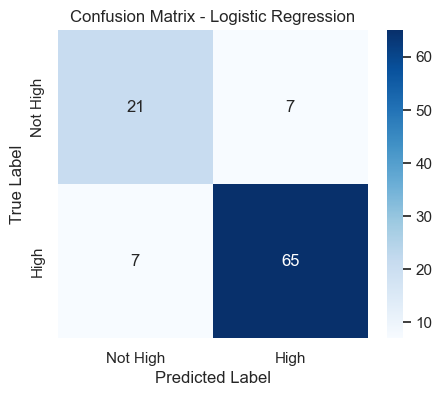

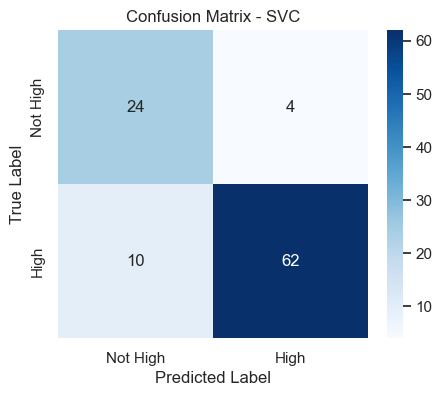

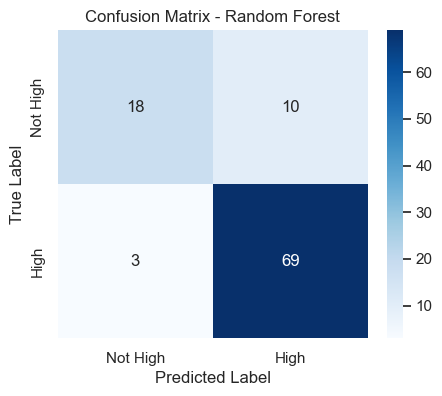

In [36]:

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not High", "High"],
                yticklabels=["Not High", "High"])
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


log_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
log_pipe.fit(Xc_train, yc_train)
log_pred = log_pipe.predict(Xc_test)


svc_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", C=1, probability=True, class_weight="balanced"))
])
svc_pipe.fit(Xc_train, yc_train)
svc_pred = svc_pipe.predict(Xc_test)


rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42))
])
rf_pipe.fit(Xc_train, yc_train)
rf_pred = rf_pipe.predict(Xc_test)


plot_conf_matrix(yc_test, log_pred, "Confusion Matrix - Logistic Regression")
plot_conf_matrix(yc_test, svc_pred, "Confusion Matrix - SVC")
plot_conf_matrix(yc_test, rf_pred, "Confusion Matrix - Random Forest")

All three models showed strong separability between the classes. The ROC curves all rise steeply toward the top-left corner, and all AUC values are above 0.90. This confirms that all models are capable of distinguishing between high and not-high happiness levels with high confidence.

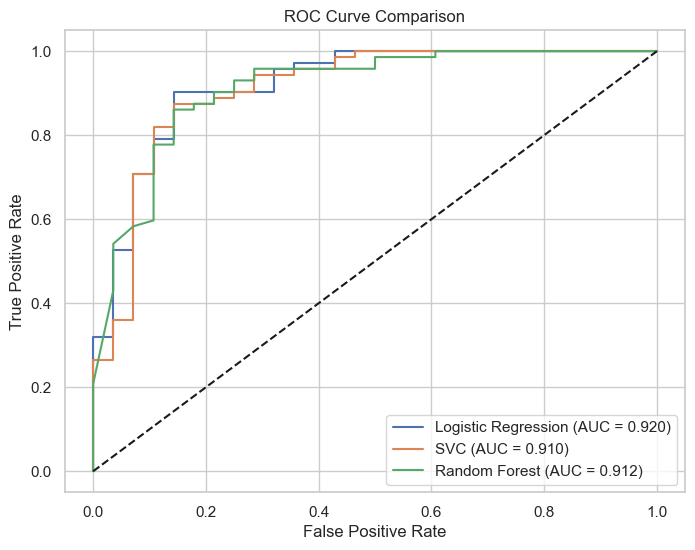

In [37]:

def get_probabilities(pipe, X):
    if hasattr(pipe["model"], "predict_proba"):
        return pipe.predict_proba(X)[:, 1]
    elif hasattr(pipe["model"], "decision_function"):

        from sklearn.preprocessing import MinMaxScaler
        scores = pipe.decision_function(X).reshape(-1, 1)
        return MinMaxScaler().fit_transform(scores).ravel()
    else:
        raise ValueError("Model does not support probability or decision function.")

# get probabilities for each model
log_probs = get_probabilities(log_pipe, Xc_test)
svc_probs = get_probabilities(svc_pipe, Xc_test)
rf_probs = get_probabilities(rf_pipe, Xc_test)

# calculation of ROC curves and AUC
log_fpr, log_tpr, _ = roc_curve(yc_test, log_probs)
svc_fpr, svc_tpr, _ = roc_curve(yc_test, svc_probs)
rf_fpr, rf_tpr, _ = roc_curve(yc_test, rf_probs)

log_auc = roc_auc_score(yc_test, log_probs)
svc_auc = roc_auc_score(yc_test, svc_probs)
rf_auc = roc_auc_score(yc_test, rf_probs)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(svc_fpr, svc_tpr, label=f"SVC (AUC = {svc_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [38]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVC", "Random Forest"],
    "Accuracy": [log_res[0], svc_res[0], rf_res[0]],
    "Precision": [log_res[1], svc_res[1], rf_res[1]],
    "Recall": [log_res[2], svc_res[2], rf_res[2]],
    "F1 Score": [log_res[3], svc_res[3], rf_res[3]],
    "AUC-ROC": [log_res[4], svc_res[4], rf_res[4]]
})

classification_results.style.background_gradient(cmap="Blues")


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.860000,0.902778,0.902778,0.902778,0.920139
1,SVC,0.860000,0.939394,0.861111,0.898551,0.910218
2,Random Forest,0.870000,0.873418,0.958333,0.913907,0.911706


## **Conclusion**
* The classification results demonstrate that the features in this dataset are quite informative for predicting whether a person has high happiness levels. All three models performed well, but **Random Forest** stands out as the best overall performer for this specific task.

* This section showed that the dataset can be used not only to predict continuous happiness scores but also to classify individuals into meaningful happiness categories.